In [12]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from pitcher_k.config import RAW_STATCAST_START, RAW_STATCAST_END
from pitcher_k.data_loader import load_statcast_data

In [7]:

from pitcher_k.preprocessing import add_outcome_flags
from pitcher_k.features import (
    build_pitcher_game_table,
    add_rolling_pitcher_features,
    add_rate_features,
    build_model_df,
)
from pitcher_k.train import time_split, train_model
from pitcher_k.evaluate import plot_actual_vs_predicted


In [13]:
sc = load_statcast_data(start_dt=RAW_STATCAST_START, end_dt=RAW_STATCAST_END)
sc = add_outcome_flags(sc)


This is a large query, it may take a moment to complete


100%|██████████| 188/188 [00:09<00:00, 19.32it/s]


In [ ]:
pitcher_games = build_pitcher_game_table(sc)
pitcher_games = add_opponent_k_features(pitcher_games, sc)
pitcher_games = add_rolling_pitcher_features(pitcher_games)
pitcher_games = add_rate_features(pitcher_games)
model_df = build_model_df(pitcher_games)


In [14]:
train_df, test_df = time_split(model_df)
train_output = train_model(train_df, test_df)


In [15]:
model = train_output["model"]
dtest = train_output["dtest"]
y_test = train_output["y_test"]

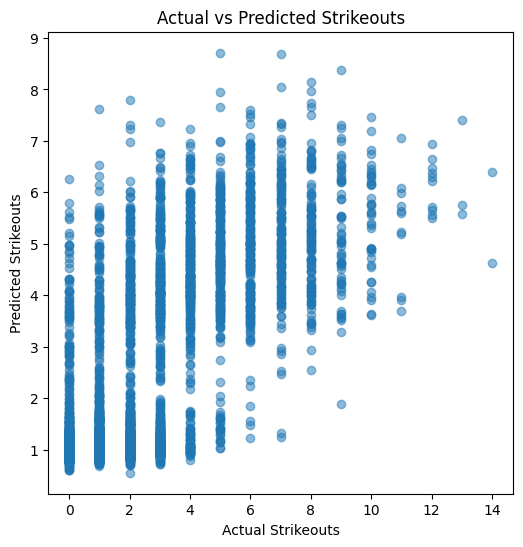

In [16]:
test_preds = model.predict(dtest)
plot_actual_vs_predicted(y_test, test_preds)